In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import numpy as np

In [5]:
# mnist 에서 제공한 fashion 예제
(X_train, y_train), (X_test, y_test) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# X_test, y_test를 이용해서 평가를 하고, X_test, y_test 중 16개를 가져와서 예측
# 학습은 1에포크만 적용(이유 시간 때문에)
# 10가지 분류명(확인용)
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
# 예측을 하면 분류 수만큼 확률이 나옴
# 왜? 모델 설계에서 출력층 활성화 함수가 softmax
# 가장 확률이 높은 분류 번호 => 타이틀

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint,ReduceLROnPlateau
# 콜백
callbacks = [
# 조기 종료
	EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True),
# 최고 성능 모델 저장 => 중간에 중지해도 중지전까지 최고 성능을 가져옵
	ModelCheckpoint(filepath='best_cifar10_model.keras',monitor='val_accuracy',
    save_best_only=True,verbose=1),
# 학습를 동적 조절(상황에 따라 줄어들도록 조절)
	ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-6)
]

In [ ]:
# 파이프라인 : 성능 향상 <= 학습중에 다음 학습 데이터를 준비
from tensorflow.data import Dataset
DATASET_SIZE = 60000 # X_train가 60000개 여서
TRAIN_SIZE = int(DATASET_SIZE * 0.8)
VAL_SIZE = int(DATASET_SIZE * 0.2)
dataset = Dataset.from_tensor_slices((X_train, y_train))
# 섞음
dataset = dataset.shuffle(buffer_size=DATASET_SIZE)
# 훈련 데이터셋
train_dataset = dataset.take(TRAIN_SIZE)
# 검증 데이터셋
val_dataset = dataset.skip(TRAIN_SIZE)
train_dataset = train_dataset.batch(128).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(128).prefetch(tf.data.AUTOTUNE) #60000개->128개

In [ ]:
# 데이터 증강 : 이미지를 돌리거나, 색상 반전등과 같이 변혈을 한 복사본을 만들어 학습
# (다양한 형태의 이미지를 준비하지 않아도 생성해서 있도록)
data_augmentation = tf.keras.Sequential([
	tf.keras.layers.RandomFlip("horizontal"), # 좌우 반전
	tf.keras.layers.RandomRotation(0.2) # 20% 범위내에서 무작위 회전
])

In [ ]:
# 모델설계
model = tf.keras.Sequential([
		tf.keras.Input(shape=(28, 28, 1)),
		# 데이터 증강
		data_augmentation, #이미지 많게 하는 효과 있습

    # 정규화
    tf.keras.layers.Rescaling(1./255),

    # 블록 1
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),# 속도상승 위에 한줄 정큐화 한번더
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    # 이때 이미지 크기 16*16

    # 블록 2
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    # tf.keras.layers.BatchNormalization(),
    # tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    # 이때 이미지 크기 8*8

    # 블록 3
    # tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.GlobalAveragePooling2D(),

    # 분류기
    tf.keras.layers.Dense(10, activation='softmax')
])

In [45]:
# 모델설정
model.compile(optimizer='adam', 
							loss='sparse_categorical_crossentropy',
							metrics=['accuracy']
)

In [46]:
# 학습
history = model.fit(
	train_dataset,
	epochs = 1,
	verbose = 1,
	validation_data=val_dataset,
	callbacks=callbacks,
	batch_size=128,
	)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.2059 - loss: 2.1118
Epoch 1: val_accuracy improved from None to 0.10015, saving model to best_cifar10_model.keras

Epoch 1: finished saving model to best_cifar10_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 177ms/step - accuracy: 0.2980 - loss: 1.9086 - val_accuracy: 0.1001 - val_loss: 2.9534 - learning_rate: 0.0010


In [48]:
# 평가
_, test_acc = model.evaluate(X_test,y_test)
print(f'정확도 : {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.1000 - loss: 2.9561
정확도 : 0.10000000149011612


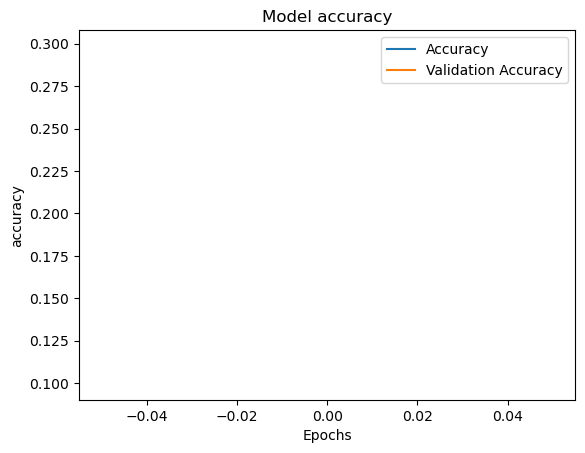

In [49]:
# 성능 시각화
# 평가
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


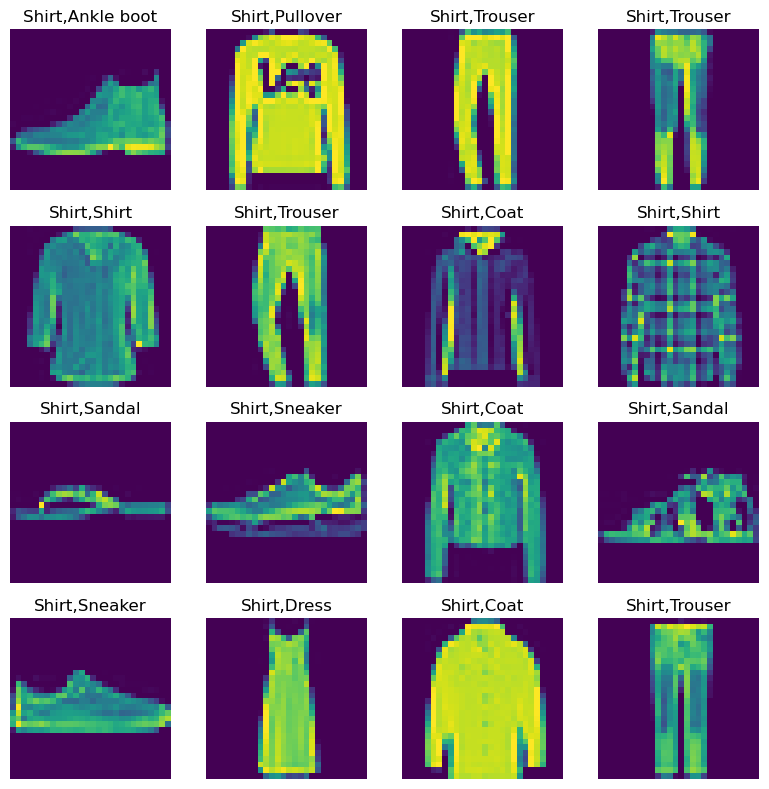

In [57]:
# 이미지 시각화
predictions = model.predict(X_test[:16])
fig, axes = plt.subplots(4, 4, figsize=(8,8))
for i, ax in enumerate(axes.flat):
	ax.imshow(X_test[i])
	predict_idx = predictions[i].argmax() # 확률이 가장 높은 값(번지)
	predict_name = class_names[predict_idx] # 확률이 가장 높은 분류명
	real_idx = y_test[i] # 실제 값(번지)
	real_name = class_names[real_idx] # 실제 분류명
	ax.set_title(f"{predict_name},{real_name}")
	ax.axis('off')
plt.tight_layout()
plt.show()